## 📦 Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Utilities
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📥 Download NLTK Data

In [2]:
import nltk

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ NLTK data downloaded!")

✅ NLTK data downloaded!


## 📁 Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('../Combined Data 2.csv')

print(f"📊 Dataset Shape: {df.shape}")
print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\n✅ Total data: {len(df):,} baris")

📊 Dataset Shape: (53043, 3)

📋 Columns: ['Unnamed: 0', 'statement', 'status']

✅ Total data: 53,043 baris


In [4]:
# Display first few rows
print("🔍 Sample Data:")
df.head()

🔍 Sample Data:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
# Dataset information
print("📊 Dataset Info:")
df.info()

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


## 🔍 Exploratory Data Analysis (EDA)

In [6]:
# Identifikasi nama kolom yang benar
# Dataset biasanya punya kolom 'statement'/'text' dan 'status'/'label'
print("📋 Nama kolom yang tersedia:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")
    print(f"   Sample: {df[col].iloc[0][:100] if isinstance(df[col].iloc[0], str) else df[col].iloc[0]}")
    print()

📋 Nama kolom yang tersedia:
1. Unnamed: 0
   Sample: 0

2. statement
   Sample: oh my gosh

3. status
   Sample: Anxiety



In [7]:
# SESUAIKAN NAMA KOLOM INI DENGAN DATASET ANDA!
# Cek output cell sebelumnya dan sesuaikan nama kolom

text_column = 'statement'  # Ganti jika nama kolom berbeda (misal: 'text', 'message', dll)
label_column = 'status'    # Ganti jika nama kolom berbeda (misal: 'label', 'category', dll)

# Rename untuk konsistensi
df = df.rename(columns={text_column: 'text', label_column: 'label'})

print(f"✅ Kolom berhasil di-rename:")
print(f"   '{text_column}' → 'text'")
print(f"   '{label_column}' → 'label'")

✅ Kolom berhasil di-rename:
   'statement' → 'text'
   'status' → 'label'


In [8]:
# Check missing values
print("❓ Missing Values:")
print(df.isnull().sum())

# Drop missing values
df = df.dropna(subset=['text', 'label'])
print(f"\n✅ Data setelah hapus missing values: {len(df):,} baris")

❓ Missing Values:
Unnamed: 0      0
text          362
label           0
dtype: int64

✅ Data setelah hapus missing values: 52,681 baris


In [9]:
# Distribusi label
print("📊 Distribusi Label:")
print(df['label'].value_counts())
print(f"\n✅ Jumlah kelas: {df['label'].nunique()}")

📊 Distribusi Label:
label
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

✅ Jumlah kelas: 7


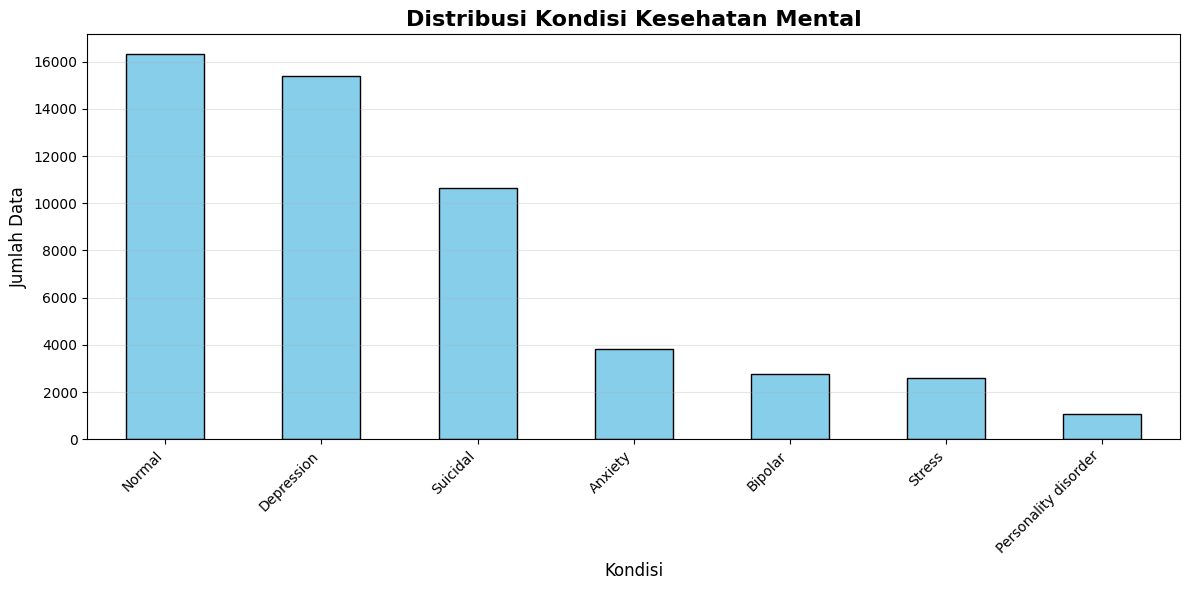

✅ Grafik disimpan: results/01_label_distribution.png


In [10]:
# Visualisasi distribusi label
plt.figure(figsize=(12, 6))
df['label'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribusi Kondisi Kesehatan Mental', fontsize=16, fontweight='bold')
plt.xlabel('Kondisi', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/01_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafik disimpan: results/01_label_distribution.png")

In [11]:
# Statistik panjang teks
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("📏 Statistik Panjang Teks:")
print(df[['text_length', 'word_count']].describe())

📏 Statistik Panjang Teks:
        text_length    word_count
count  52681.000000  52681.000000
mean     578.713863    113.158729
std      846.269078    163.735305
min        2.000000      1.000000
25%       80.000000     15.000000
50%      317.000000     62.000000
75%      752.000000    148.000000
max    32759.000000   6300.000000


## 🧹 Text Cleaning

In [12]:
def clean_text(text):
    """
    Fungsi untuk membersihkan teks:
    1. Lowercase
    2. Hapus URL
    3. Hapus mention (@username)
    4. Hapus hashtag (#hashtag)
    5. Hapus angka
    6. Hapus punctuation
    7. Hapus whitespace berlebih
    """
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove URL
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 3. Remove mention dan hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # 4. Remove angka
    text = re.sub(r'\d+', '', text)
    
    # 5. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 6. Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

print("✅ Fungsi clean_text() siap digunakan")

✅ Fungsi clean_text() siap digunakan


In [13]:
# Apply cleaning
print("🧹 Cleaning text...")
df['cleaned_text'] = df['text'].apply(clean_text)

# Remove empty texts
df = df[df['cleaned_text'].str.len() > 0]

print(f"✅ Text cleaning selesai!")
print(f"   Data tersisa: {len(df):,} baris")

🧹 Cleaning text...
✅ Text cleaning selesai!
   Data tersisa: 52,659 baris


In [14]:
# Contoh hasil cleaning
print("🔍 Contoh Hasil Cleaning:\n")
for i in range(3):
    print(f"{'='*80}")
    print(f"📌 Sample {i+1}:")
    print(f"\nOriginal Text:")
    print(f"{df.iloc[i]['text'][:150]}...\n")
    print(f"Cleaned Text:")
    print(f"{df.iloc[i]['cleaned_text'][:150]}...")
    print()

🔍 Contoh Hasil Cleaning:

📌 Sample 1:

Original Text:
oh my gosh...

Cleaned Text:
oh my gosh...

📌 Sample 2:

Original Text:
trouble sleeping, confused mind, restless heart. All out of tune...

Cleaned Text:
trouble sleeping confused mind restless heart all out of tune...

📌 Sample 3:

Original Text:
All wrong, back off dear, forward doubt. Stay in a restless and restless place...

Cleaned Text:
all wrong back off dear forward doubt stay in a restless and restless place...



## 🔤 Stopword Removal (untuk LSTM)

In [15]:
def remove_stopwords(text):
    """
    Tokenization dan stopword removal
    Digunakan untuk model LSTM
    """
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    # Join back
    return ' '.join(tokens)

print("✅ Fungsi remove_stopwords() siap")

✅ Fungsi remove_stopwords() siap


In [16]:
# Apply stopword removal untuk LSTM
print("🔤 Removing stopwords untuk LSTM...")
df['processed_text'] = df['cleaned_text'].apply(remove_stopwords)

print("✅ Stopword removal selesai!")

🔤 Removing stopwords untuk LSTM...
✅ Stopword removal selesai!


In [17]:
# Contoh hasil stopword removal
print("🔍 Contoh Hasil Stopword Removal:\n")
print(f"{'='*80}")
print(f"Cleaned Text (dengan stopwords):")
print(f"{df.iloc[0]['cleaned_text'][:150]}...\n")
print(f"Processed Text (tanpa stopwords):")
print(f"{df.iloc[0]['processed_text'][:150]}...")
print(f"{'='*80}")

🔍 Contoh Hasil Stopword Removal:

Cleaned Text (dengan stopwords):
oh my gosh...

Processed Text (tanpa stopwords):
gosh...


## 🏷️ Label Encoding

In [18]:
# Label Encoding
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Display label mapping
print("🏷️ Label Mapping:")
print(f"{'='*50}")
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
for label, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    count = len(df[df['label'] == label])
    print(f"{code}. {label:25s} → {count:,} samples")

num_classes = len(label_encoder.classes_)
print(f"{'='*50}")
print(f"✅ Total classes: {num_classes}")

🏷️ Label Mapping:
0. Anxiety                   → 3,841 samples
1. Bipolar                   → 2,777 samples
2. Depression                → 15,396 samples
3. Normal                    → 16,336 samples
4. Personality disorder      → 1,077 samples
5. Stress                    → 2,585 samples
6. Suicidal                  → 10,647 samples
✅ Total classes: 7


## ✂️ Train-Validation-Test Split

In [19]:
# Persiapkan data untuk split
# Kita akan simpan 3 versi:
# 1. processed_text (untuk LSTM - tanpa stopwords)
# 2. cleaned_text (untuk BERT/DistilBERT - dengan stopwords)
# 3. label_encoded (untuk semua model)

# Split 70% train, 15% validation, 15% test
# Stratified untuk menjaga proporsi label

print("✂️ Splitting data...\n")

# First split: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    df.index,
    test_size=0.3,
    random_state=42,
    stratify=df['label_encoded']
)

# Second split: 50% of temp = 15% validation, 15% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=df.loc[temp_idx, 'label_encoded']
)

# Create dataframes
train_df = df.loc[train_idx].reset_index(drop=True)
val_df = df.loc[val_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

print("📊 Data Split Summary:")
print(f"{'='*60}")
print(f"Training Set:   {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation Set: {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test Set:       {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")
print(f"{'='*60}")
print(f"Total:          {len(df):,} samples")

✂️ Splitting data...

📊 Data Split Summary:
Training Set:   36,861 samples (70.0%)
Validation Set: 7,899 samples (15.0%)
Test Set:       7,899 samples (15.0%)
Total:          52,659 samples


In [20]:
# Verifikasi distribusi label di setiap split
print("✅ Verifikasi Stratified Split:\n")

print("📊 Training Set:")
print(train_df['label'].value_counts().sort_index())
print()

print("📊 Validation Set:")
print(val_df['label'].value_counts().sort_index())
print()

print("📊 Test Set:")
print(test_df['label'].value_counts().sort_index())

✅ Verifikasi Stratified Split:

📊 Training Set:
label
Anxiety                  2689
Bipolar                  1944
Depression              10777
Normal                  11435
Personality disorder      754
Stress                   1809
Suicidal                 7453
Name: count, dtype: int64

📊 Validation Set:
label
Anxiety                  576
Bipolar                  416
Depression              2310
Normal                  2450
Personality disorder     162
Stress                   388
Suicidal                1597
Name: count, dtype: int64

📊 Test Set:
label
Anxiety                  576
Bipolar                  417
Depression              2309
Normal                  2451
Personality disorder     161
Stress                   388
Suicidal                1597
Name: count, dtype: int64


## 💾 Simpan Hasil Preprocessing

In [21]:
# Create output directory if not exists
os.makedirs('../data/processed', exist_ok=True)

print("💾 Menyimpan hasil preprocessing...\n")

💾 Menyimpan hasil preprocessing...



In [22]:
# 1. Simpan dataframes ke CSV
train_df.to_csv('../data/processed/train.csv', index=False)
val_df.to_csv('../data/processed/val.csv', index=False)
test_df.to_csv('../data/processed/test.csv', index=False)

print("✅ CSV files saved:")
print("   - data/processed/train.csv")
print("   - data/processed/val.csv")
print("   - data/processed/test.csv")

✅ CSV files saved:
   - data/processed/train.csv
   - data/processed/val.csv
   - data/processed/test.csv


In [23]:
# 2. Simpan Label Encoder
with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("\n✅ Label Encoder saved:")
print("   - models/label_encoder.pkl")


✅ Label Encoder saved:
   - models/label_encoder.pkl


In [24]:
# 3. Simpan metadata
metadata = {
    'num_classes': num_classes,
    'classes': label_encoder.classes_.tolist(),
    'label_mapping': label_mapping,
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'total_size': len(df),
    'preprocessing_steps': [
        'lowercase',
        'remove_url',
        'remove_mentions',
        'remove_hashtags',
        'remove_numbers',
        'remove_punctuation',
        'remove_extra_whitespace',
        'stopword_removal (for LSTM)'
    ]
}

with open('../data/processed/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("\n✅ Metadata saved:")
print("   - data/processed/metadata.pkl")


✅ Metadata saved:
   - data/processed/metadata.pkl


## 📋 Summary Preprocessing

In [25]:
print("\n" + "="*80)
print("📋 PREPROCESSING SUMMARY")
print("="*80)

print(f"\n✅ Dataset: Combined Data 2.csv")
print(f"✅ Total Data: {len(df):,} baris")
print(f"✅ Jumlah Kelas: {num_classes}")

print(f"\n📊 Data Split:")
print(f"   - Training:   {len(train_df):,} samples (70%)")
print(f"   - Validation: {len(val_df):,} samples (15%)")
print(f"   - Test:       {len(test_df):,} samples (15%)")

print(f"\n🏷️ Label Classes:")
for i, label in enumerate(label_encoder.classes_, 1):
    print(f"   {i}. {label}")

print(f"\n💾 Files Saved:")
print(f"   ✓ data/processed/train.csv")
print(f"   ✓ data/processed/val.csv")
print(f"   ✓ data/processed/test.csv")
print(f"   ✓ models/label_encoder.pkl")
print(f"   ✓ data/processed/metadata.pkl")
print(f"   ✓ results/01_label_distribution.png")

print(f"\n🎯 Ready for Model Training!")
print(f"   → Next: 02_lstm_model.ipynb")
print("="*80)


📋 PREPROCESSING SUMMARY

✅ Dataset: Combined Data 2.csv
✅ Total Data: 52,659 baris
✅ Jumlah Kelas: 7

📊 Data Split:
   - Training:   36,861 samples (70%)
   - Validation: 7,899 samples (15%)
   - Test:       7,899 samples (15%)

🏷️ Label Classes:
   1. Anxiety
   2. Bipolar
   3. Depression
   4. Normal
   5. Personality disorder
   6. Stress
   7. Suicidal

💾 Files Saved:
   ✓ data/processed/train.csv
   ✓ data/processed/val.csv
   ✓ data/processed/test.csv
   ✓ models/label_encoder.pkl
   ✓ data/processed/metadata.pkl
   ✓ results/01_label_distribution.png

🎯 Ready for Model Training!
   → Next: 02_lstm_model.ipynb
